# CI/CD Energy Analysis
### GreenDevOps
---

## 0. Installation des dépendances

In [10]:
%%bash
pip install influxdb-client pandas numpy scipy scikit-learn shap matplotlib seaborn glob2 --break-system-packages -q

## 1. Imports & Configuration globale

In [18]:
import os, glob, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from datetime import datetime, timezone

# InfluxDB
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (14, 6), 'figure.dpi': 120, 'axes.titleweight': 'bold'})

# ── CONFIG ──────────────────────────────────────────────────────
BASE_PATH    = os.path.expanduser('~/GreenDevOps/jobs_energy')
INFLUX_URL   = 'http://localhost:8086'
INFLUX_TOKEN = '9W0II8Iy9JDXG9NNQiTaBIW9DFahLkZmCZIwPff73__oD5ATaUueVSd6ybvRBvQxqblcS0uMtCrn7Rp7sTfiPw=='           
INFLUX_ORG   = 'green_energy_org'
INFLUX_BUCKET= 'cicd_energy'

ENERGY_COLS  = ['cpu_j','ram_j','sd_j','nic_j','gpu_j','total_energy_j']
COMP_COLS    = ['cpu_j','ram_j','sd_j','nic_j','gpu_j']
SIGMA_THRESH = 3.0
MAX_INTERP   = 5       # gap courts → interpolation linéaire
MAX_FFILL    = 20      # gap moyens → forward-fill
BATCH_SIZE   = 500

print('✅ Imports OK')
print(f'📂 Base path : {BASE_PATH}')

✅ Imports OK
📂 Base path : /home/medyassine/GreenDevOps/jobs_energy


## 2. EXTRACT — Scan & Chargement de tous les CSV
Lecture de :
- `global_history/master_energy_database.csv` → table des jobs
- `granularity/history_<job>_<component>.csv` → séries temporelles par composant
- `pipelines_total/pipeline_summary.csv` → résumé par pipeline

In [6]:
def parse_date_robust(s: pd.Series) -> pd.Series:
    """Gère les formats YYYY-MM-DD HH:MM:SS et YYYY-MM-DD_HH:MM:SS."""
    s = s.astype(str).str.replace('_', ' ', regex=False)
    return pd.to_datetime(s, format='%Y-%m-%d %H:%M:%S', errors='coerce')

def snake_case(col: str) -> str:
    """camelCase / PascalCase → snake_case, normalise les espaces."""
    col = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1_\2', col)
    col = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col)
    return col.lower().strip().replace(' ', '_').replace('-', '_')

def cast_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Force les colonnes énergie en float (gère les virgules comme séparateur décimal)."""
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(
                df[c].astype(str).str.replace(',', '.', regex=False),
                errors='coerce'
            )
    return df

# ── Chargement master_energy_database ──────────────────────────
def load_master_db(base_dir: str) -> pd.DataFrame:
    pattern = os.path.join(base_dir, '*', 'global_history', 'master_energy_database.csv')
    files   = glob.glob(pattern)
    frames  = []
    for fp in files:
        df = pd.read_csv(fp, dtype=str)
        df.columns = [snake_case(c) for c in df.columns]
        df['repo_name'] = os.path.basename(os.path.dirname(os.path.dirname(fp)))
        df['_source_file'] = os.path.basename(fp)
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'Aucun master_energy_database.csv trouvé sous {base_dir}')
    df_all = pd.concat(frames, ignore_index=True)
    df_all = cast_numeric(df_all, ENERGY_COLS + ['duration_s'])
    df_all['date'] = parse_date_robust(df_all['date'])
    return df_all

# ── Chargement granularity (séries par composant) ───────────────
def load_granularity(base_dir: str) -> pd.DataFrame:
    pattern = os.path.join(base_dir, '*', 'granularity', 'history_*.csv')
    files   = glob.glob(pattern)
    frames  = []
    for fp in files:
        fname   = os.path.basename(fp)          # history_build_cpu.csv
        parts   = fname.replace('.csv','').split('_')
        job_    = '_'.join(parts[1:-1])          # build / docker-build / …
        comp_   = parts[-1]                      # cpu / ram / sd / nic / gpu
        df = pd.read_csv(fp, dtype=str)
        df.columns = [snake_case(c) for c in df.columns]
        df['job_name']   = job_
        df['component']  = comp_
        df['repo_folder']= os.path.basename(os.path.dirname(os.path.dirname(fp)))
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'Aucun fichier granularity trouvé sous {base_dir}')
    df_all = pd.concat(frames, ignore_index=True)
    numeric_g = ['duration_s','avg_power_w','total_energy_j','samples']
    df_all = cast_numeric(df_all, numeric_g)
    df_all['date'] = parse_date_robust(df_all['date'])
    return df_all

# ── Chargement pipeline_summary ─────────────────────────────────
def load_pipeline_summary(base_dir: str) -> pd.DataFrame:
    pattern = os.path.join(base_dir, '*', 'pipelines_total', 'pipeline_summary.csv')
    files   = glob.glob(pattern)
    frames  = []
    for fp in files:
        df = pd.read_csv(fp, dtype=str)
        df.columns = [snake_case(c) for c in df.columns]
        df['repo_folder'] = os.path.basename(os.path.dirname(os.path.dirname(fp)))
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'Aucun pipeline_summary.csv trouvé sous {base_dir}')
    df_all = pd.concat(frames, ignore_index=True)
    df_all = cast_numeric(df_all, ['total_pipeline_energy_j'])
    df_all['date'] = parse_date_robust(df_all['date'])
    return df_all

df_master  = load_master_db(BASE_PATH)
df_gran    = load_granularity(BASE_PATH)
df_pipe    = load_pipeline_summary(BASE_PATH)

print(f'✅ master_db   : {df_master.shape[0]:>5} lignes × {df_master.shape[1]} cols')
print(f'✅ granularity : {df_gran.shape[0]:>5} lignes × {df_gran.shape[1]} cols')
print(f'✅ pipeline    : {df_pipe.shape[0]:>5} lignes × {df_pipe.shape[1]} cols')
df_master.head(3)

✅ master_db   :   402 lignes × 17 cols
✅ granularity :  2190 lignes × 15 cols
✅ pipeline    :    62 lignes × 10 cols


,date,pipeline_id,commit_id,repo_name,project_name,category,branch,trigger,job_name,duration_s,cpu_j,ram_j,sd_j,nic_j,gpu_j,total_energy_j,_source_file
0,2026-03-27 16:31:22,23654101757,0bd2170,green_energy_org_green_devops,Chatbot-LLM,IA,main,auto,setup,9.0,2.52,13.60,0.57,0.0,0.0,16.69,master_energy_database.csv
1,2026-03-27 16:31:39,23654101757,0bd2170,green_energy_org_green_devops,Chatbot-LLM,IA,main,auto,install,5.0,1.61,13.01,0.03,0.0,0.0,14.65,master_energy_database.csv
2,2026-03-27 16:32:32,23654101757,0bd2170,green_energy_org_green_devops,Chatbot-LLM,IA,main,auto,lint,40.0,3.11,16.22,0.62,0.0,0.0,19.95,master_energy_database.csv


## 3. NORMALIZE — Uniformisation, Déduplication, Labels

In [7]:
def normalize_df(df: pd.DataFrame, label_col='project_name') -> pd.DataFrame:
    """Répare les labels vides, déduplique, réindexe."""
    # Réparer project_name / category vides depuis repo_name
    if label_col in df.columns and 'repo_name' in df.columns:
        mask = df[label_col].isna() | (df[label_col].astype(str).str.strip() == '')
        df.loc[mask, label_col] = (
            df.loc[mask, 'repo_name']
              .str.replace('green_energy_org_', '', regex=False)
              .str.upper()
        )
    if 'category' in df.columns:
        df['category'].fillna('UNKNOWN', inplace=True)

    # Dédupliquation stricte
    before = len(df)
    subset_cols = [c for c in ['pipeline_id','job_name','date','component'] if c in df.columns]
    df = df.drop_duplicates(subset=subset_cols).reset_index(drop=True)
    after = len(df)
    if before != after:
        print(f'  ↳ {before-after} doublons supprimés')
    return df

df_master = normalize_df(df_master)
df_gran   = normalize_df(df_gran, label_col='project_name')
df_pipe   = normalize_df(df_pipe)

# Statistiques rapides
print('\n── master_db ──')
print(df_master[ENERGY_COLS].describe().round(3))

  ↳ 4 doublons supprimés
  ↳ 20 doublons supprimés
  ↳ 3 doublons supprimés

── master_db ──
         cpu_j    ram_j     sd_j    nic_j  gpu_j  total_energy_j
count  389.000  389.000  389.000  389.000  389.0         389.000
mean     4.306   10.695    0.077    0.000    0.0          15.078
std     14.480   16.224    0.198    0.003    0.0          29.242
min      0.000    0.000    0.000    0.000    0.0           0.000
25%      0.320    3.790    0.000    0.000    0.0           4.080
50%      0.730    6.280    0.010    0.000    0.0           7.170
75%      1.740   10.040    0.050    0.000    0.0          12.260
max    110.730   86.690    1.870    0.050    0.0         186.850


## 4. DETECT ANOMALIES — Zéros suspects, valeurs négatives, outliers (> 3σ)

In [8]:
def detect_anomalies(df: pd.DataFrame, cols: list, name: str='df') -> pd.DataFrame:
    """
    Retourne un rapport d'anomalies :
    - zeros_seq  : séquences ≥3 zéros consécutifs (par pipeline/job)
    - negatives  : valeurs < 0
    - outliers   : z-score absolu > SIGMA_THRESH
    """
    report = []
    for col in cols:
        if col not in df.columns:
            continue
        s = df[col].copy()

        # 1. Valeurs négatives
        neg_mask = s < 0
        if neg_mask.any():
            report.append({'dataset': name, 'column': col,
                           'type': 'negative', 'count': neg_mask.sum(),
                           'indices': df.index[neg_mask].tolist()[:5]})

        # 2. Outliers z-score
        z = np.abs(stats.zscore(s.dropna()))
        out_idx = s.dropna().index[z > SIGMA_THRESH]
        if len(out_idx):
            report.append({'dataset': name, 'column': col,
                           'type': 'outlier_3sigma', 'count': len(out_idx),
                           'indices': out_idx.tolist()[:5]})

        # 3. Séquences de zéros suspects (≥3 consécutifs)
        zero_runs = (s == 0).astype(int)
        run_len   = zero_runs.groupby((zero_runs != zero_runs.shift()).cumsum()).transform('sum')
        susp_mask = (zero_runs == 1) & (run_len >= 3)
        if susp_mask.any():
            report.append({'dataset': name, 'column': col,
                           'type': 'zero_sequence', 'count': int(susp_mask.sum()),
                           'indices': df.index[susp_mask].tolist()[:5]})

    return pd.DataFrame(report)

anom_master = detect_anomalies(df_master, ENERGY_COLS, 'master_db')
anom_gran   = detect_anomalies(df_gran, ['avg_power_w','total_energy_j'], 'granularity')
anom_pipe   = detect_anomalies(df_pipe, ['total_pipeline_energy_j'], 'pipeline')

report_all = pd.concat([anom_master, anom_gran, anom_pipe], ignore_index=True)
print(f'🔍 {len(report_all)} types d anomalies détectées')
print(report_all[['dataset','column','type','count']].to_string(index=False))

🔍 15 types d anomalies détectées
    dataset         column           type  count
  master_db          cpu_j outlier_3sigma      9
  master_db          cpu_j  zero_sequence     15
  master_db          ram_j outlier_3sigma     17
  master_db          ram_j  zero_sequence     48
  master_db           sd_j outlier_3sigma      7
  master_db           sd_j  zero_sequence     86
  master_db          nic_j outlier_3sigma      2
  master_db          nic_j  zero_sequence    387
  master_db          gpu_j  zero_sequence    389
  master_db total_energy_j outlier_3sigma     10
  master_db total_energy_j  zero_sequence     15
granularity    avg_power_w outlier_3sigma     43
granularity    avg_power_w  zero_sequence   1055
granularity total_energy_j outlier_3sigma     43
granularity total_energy_j  zero_sequence   1069


### 4.1 Visualisation des anomalies

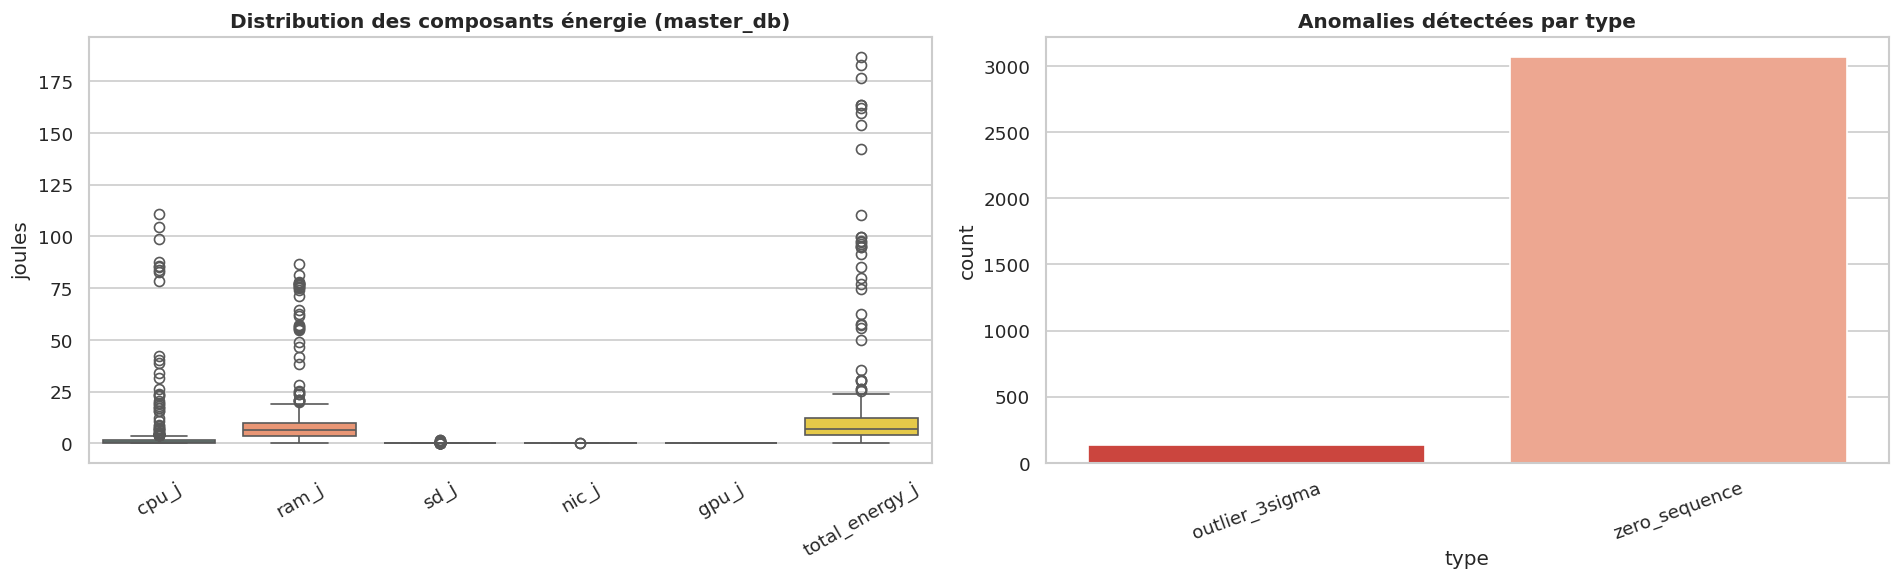

✅ Graphique anomalies sauvegardé


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot des colonnes énergie (outliers visibles)
df_melt = df_master[ENERGY_COLS].melt(var_name='composant', value_name='joules')
sns.boxplot(ax=axes[0], data=df_melt, x='composant', y='joules', palette='Set2')
axes[0].set_title('Distribution des composants énergie (master_db)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Distribution des anomalies par type
if not report_all.empty:
    pivot = report_all.groupby(['type'])['count'].sum().reset_index()
    sns.barplot(ax=axes[1], data=pivot, x='type', y='count', palette='Reds_r', hue='type', legend=False)
    axes[1].set_title("Anomalies détectées par type")
    axes[1].tick_params(axis='x', rotation=20)
else:
    axes[1].text(0.5, 0.5, 'Aucune anomalie', ha='center', va='center', fontsize=14)
    axes[1].set_title('Anomalies')

plt.tight_layout()
plt.savefig('anomaly_report.png', bbox_inches='tight')
plt.show()
print('✅ Graphique anomalies sauvegardé')

## 5. Interpolation & Forward-fill
- Gaps courts (< 5 intervalles) → **interpolation linéaire**
- Gaps moyens (5–20 intervalles) → **forward-fill**
- Valeurs négatives → remplacées par `NaN` puis interpolées
- Outliers 3σ → clipping au percentile 99

In [10]:
def correct_series(s: pd.Series) -> pd.Series:
    """Applique les corrections dans l'ordre: négatifs → outliers → interpolation/ffill."""
    s = s.copy().astype(float)

    # 1. Valeurs négatives → NaN
    s[s < 0] = np.nan

    # 2. Outliers → clip au p99 (par valeur absolue)
    p99 = s.quantile(0.99)
    s = s.clip(upper=p99)

    # 3. Identifier les runs de NaN
    is_null = s.isna()
    if not is_null.any():
        return s

    # Calcul de la longueur de chaque run de NaN
    null_groups = (is_null != is_null.shift()).cumsum()
    run_lengths = is_null.groupby(null_groups).transform('sum')

    # Gaps courts → interpolation linéaire
    short_gap = is_null & (run_lengths <= MAX_INTERP)
    s_interp  = s.interpolate(method='linear', limit=MAX_INTERP)
    s[short_gap] = s_interp[short_gap]

    # Gaps moyens → forward-fill
    med_gap = s.isna() & (run_lengths <= MAX_FFILL)
    s_ff    = s.ffill()
    s[med_gap] = s_ff[med_gap]

    # Restants → 0 (données manquantes irréparables)
    s.fillna(0, inplace=True)
    return s

def correct_dataframe(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = correct_series(df[c])
    return df

df_master_clean = correct_dataframe(df_master,  ENERGY_COLS + ['duration_s'])
df_gran_clean   = correct_dataframe(df_gran,    ['avg_power_w','total_energy_j','duration_s'])
df_pipe_clean   = correct_dataframe(df_pipe,    ['total_pipeline_energy_j'])

# Vérification
remaining_null = df_master_clean[ENERGY_COLS].isnull().sum().sum()
print(f'✅ Correction terminée — NaN résiduels dans master_db: {remaining_null}')
print(df_master_clean[ENERGY_COLS].describe().round(3))

✅ Correction terminée — NaN résiduels dans master_db: 0
         cpu_j    ram_j     sd_j  nic_j  gpu_j  total_energy_j
count  398.000  398.000  398.000  398.0  398.0         398.000
mean     4.085   10.570    0.069    0.0    0.0          14.771
std     13.359   15.897    0.153    0.0    0.0          28.150
min      0.000    0.000    0.000    0.0    0.0           0.000
25%      0.320    3.860    0.000    0.0    0.0           4.152
50%      0.755    6.350    0.010    0.0    0.0           7.255
75%      1.728    9.918    0.050    0.0    0.0          11.988
max     85.861   77.452    0.729    0.0    0.0         163.500


## 6. LOAD — Insertion batch dans InfluxDB 2.x

In [19]:
def df_to_points(df: pd.DataFrame, measurement: str, tag_cols: list, field_cols: list):
    """Convertit un DataFrame en liste de Points InfluxDB."""
    points = []
    for _, row in df.iterrows():
        ts = row.get('date')
        if pd.isna(ts):
            continue
        p = Point(measurement).time(ts.to_pydatetime().replace(tzinfo=timezone.utc),
                                    WritePrecision.S)
        for tc in tag_cols:
            val = row.get(tc)
            if pd.notna(val):
                p = p.tag(tc, str(val))
        for fc in field_cols:
            val = row.get(fc)
            if pd.notna(val):
                p = p.field(fc, float(val))
        points.append(p)
    return points

def write_to_influx(points: list, url: str, token: str, org: str, bucket: str):
    """Insère par batch de BATCH_SIZE."""
    try:
        client = InfluxDBClient(url=url, token=token, org=org)
        write_api = client.write_api(write_options=SYNCHRONOUS)
        for i in range(0, len(points), BATCH_SIZE):
            batch = points[i:i+BATCH_SIZE]
            write_api.write(bucket=bucket, org=org, record=batch)
            print(f'  ↳ Batch {i//BATCH_SIZE+1} — {len(batch)} points insérés')
        client.close()
        print(f'✅ {len(points)} points totaux écrits dans [{bucket}]')
    except Exception as e:
        print(f'⚠️  InfluxDB non disponible ({e})')
        print('   → Les données nettoyées restent disponibles dans les DataFrames pandas.')

TAG_MASTER  = ['repo_name', 'project_name', 'category', 'branch', 'trigger', 'job_name', 'commit_id', 'pipeline_id']
FIELD_MASTER = ENERGY_COLS + ['duration_s']

TAG_GRAN    = ['repo_name', 'project_name', 'job_name', 'component', 'branch', 'trigger', 'pipeline_id']
FIELD_GRAN  = ['avg_power_w', 'total_energy_j', 'duration_s', 'samples']

TAG_PIPE    = ['repo_name', 'project_name', 'branch', 'trigger', 'commit_id', 'pipeline_id']
FIELD_PIPE  = ['total_pipeline_energy_j']

pts_master = df_to_points(df_master_clean, 'job_energy',      TAG_MASTER, FIELD_MASTER)
pts_gran   = df_to_points(df_gran_clean,   'job_granularity', TAG_GRAN,   FIELD_GRAN)
pts_pipe   = df_to_points(df_pipe_clean,   'pipeline_energy', TAG_PIPE,   FIELD_PIPE)

print(f'📦 Points prêts → master:{len(pts_master)} | gran:{len(pts_gran)} | pipe:{len(pts_pipe)}')
write_to_influx(pts_master, INFLUX_URL, INFLUX_TOKEN, INFLUX_ORG, INFLUX_BUCKET)
write_to_influx(pts_gran,   INFLUX_URL, INFLUX_TOKEN, INFLUX_ORG, INFLUX_BUCKET)
write_to_influx(pts_pipe,   INFLUX_URL, INFLUX_TOKEN, INFLUX_ORG, INFLUX_BUCKET)

📦 Points prêts → master:390 | gran:2090 | pipe:55
  ↳ Batch 1 — 390 points insérés
✅ 390 points totaux écrits dans [cicd_energy]
  ↳ Batch 1 — 500 points insérés
  ↳ Batch 2 — 500 points insérés
  ↳ Batch 3 — 500 points insérés
  ↳ Batch 4 — 500 points insérés
  ↳ Batch 5 — 90 points insérés
✅ 2090 points totaux écrits dans [cicd_energy]
  ↳ Batch 1 — 55 points insérés
✅ 55 points totaux écrits dans [cicd_energy]


## 7. RELOAD depuis InfluxDB (ou Pandas si InfluxDB offline)
Merge CPU/GPU/RAM/SD/NIC sur timestamp + pipeline_id pour l'analyse ML.

In [20]:
def query_influx_or_fallback(url, token, org, bucket, measurement, fallback_df):
    """Tente une requête Flux — retombe sur le DataFrame pandas si InfluxDB est offline."""
    try:
        client = InfluxDBClient(url=url, token=token, org=org)
        query  = f'''
        from(bucket: "{bucket}")
          |> range(start: -90d)
          |> filter(fn: (r) => r._measurement == "{measurement}")
          |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
          |> keep(columns: ["_time", "repo_name", "job_name", "pipeline_id", "cpu_j", "ram_j",
                             "sd_j", "nic_j", "gpu_j", "total_energy_j",
                             "duration_s", "project_name"])
        '''
        df_q = client.query_api().query_data_frame(query, org=org)
        client.close()
        if isinstance(df_q, list):
            df_q = pd.concat(df_q)
        df_q.rename(columns={'_time':'date'}, inplace=True)
        print(f'✅ Chargé depuis InfluxDB : {len(df_q)} lignes')
        return df_q
    except Exception as e:
        print(f'⚠️  Fallback pandas ({e})')
        return fallback_df.copy()

df_analysis = query_influx_or_fallback(
    INFLUX_URL, INFLUX_TOKEN, INFLUX_ORG, INFLUX_BUCKET,
    'job_energy', df_master_clean
)

# Merge avec les données granulaires (pivot component → colonnes avg_power_w)
df_gran_pivot = (
    df_gran_clean.pivot_table(
        index=['pipeline_id','job_name','date'],
        columns='component',
        values='avg_power_w',
        aggfunc='mean'
    )
    .rename(columns=lambda c: f'power_{c}_w')
    .reset_index()
)

df_merged = df_analysis.merge(
    df_gran_pivot, on=['pipeline_id','job_name'], how='left', suffixes=('','_gran')
)
# Garder la date principale
if 'date_gran' in df_merged.columns:
    df_merged.drop(columns=['date_gran'], inplace=True)

df_merged.sort_values('date', inplace=True)
df_merged.reset_index(drop=True, inplace=True)

print(f'\n📊 DataFrame analyse final : {df_merged.shape}')
print('Colonnes:', df_merged.columns.tolist())

✅ Chargé depuis InfluxDB : 390 lignes

📊 DataFrame analyse final : (595, 19)
Colonnes: ['result', 'table', 'date', 'job_name', 'pipeline_id', 'project_name', 'repo_name', 'cpu_j', 'duration_s', 'gpu_j', 'nic_j', 'ram_j', 'sd_j', 'total_energy_j', 'power_cpu_w', 'power_gpu_w', 'power_nic_w', 'power_ram_w', 'power_sd_w']


## 8. Analyse de Distribution — Histogrammes, Boxplots, Skewness

ℹ️ KDE sauté pour nic_j : données constantes ou uniques.
ℹ️ KDE sauté pour gpu_j : données constantes ou uniques.


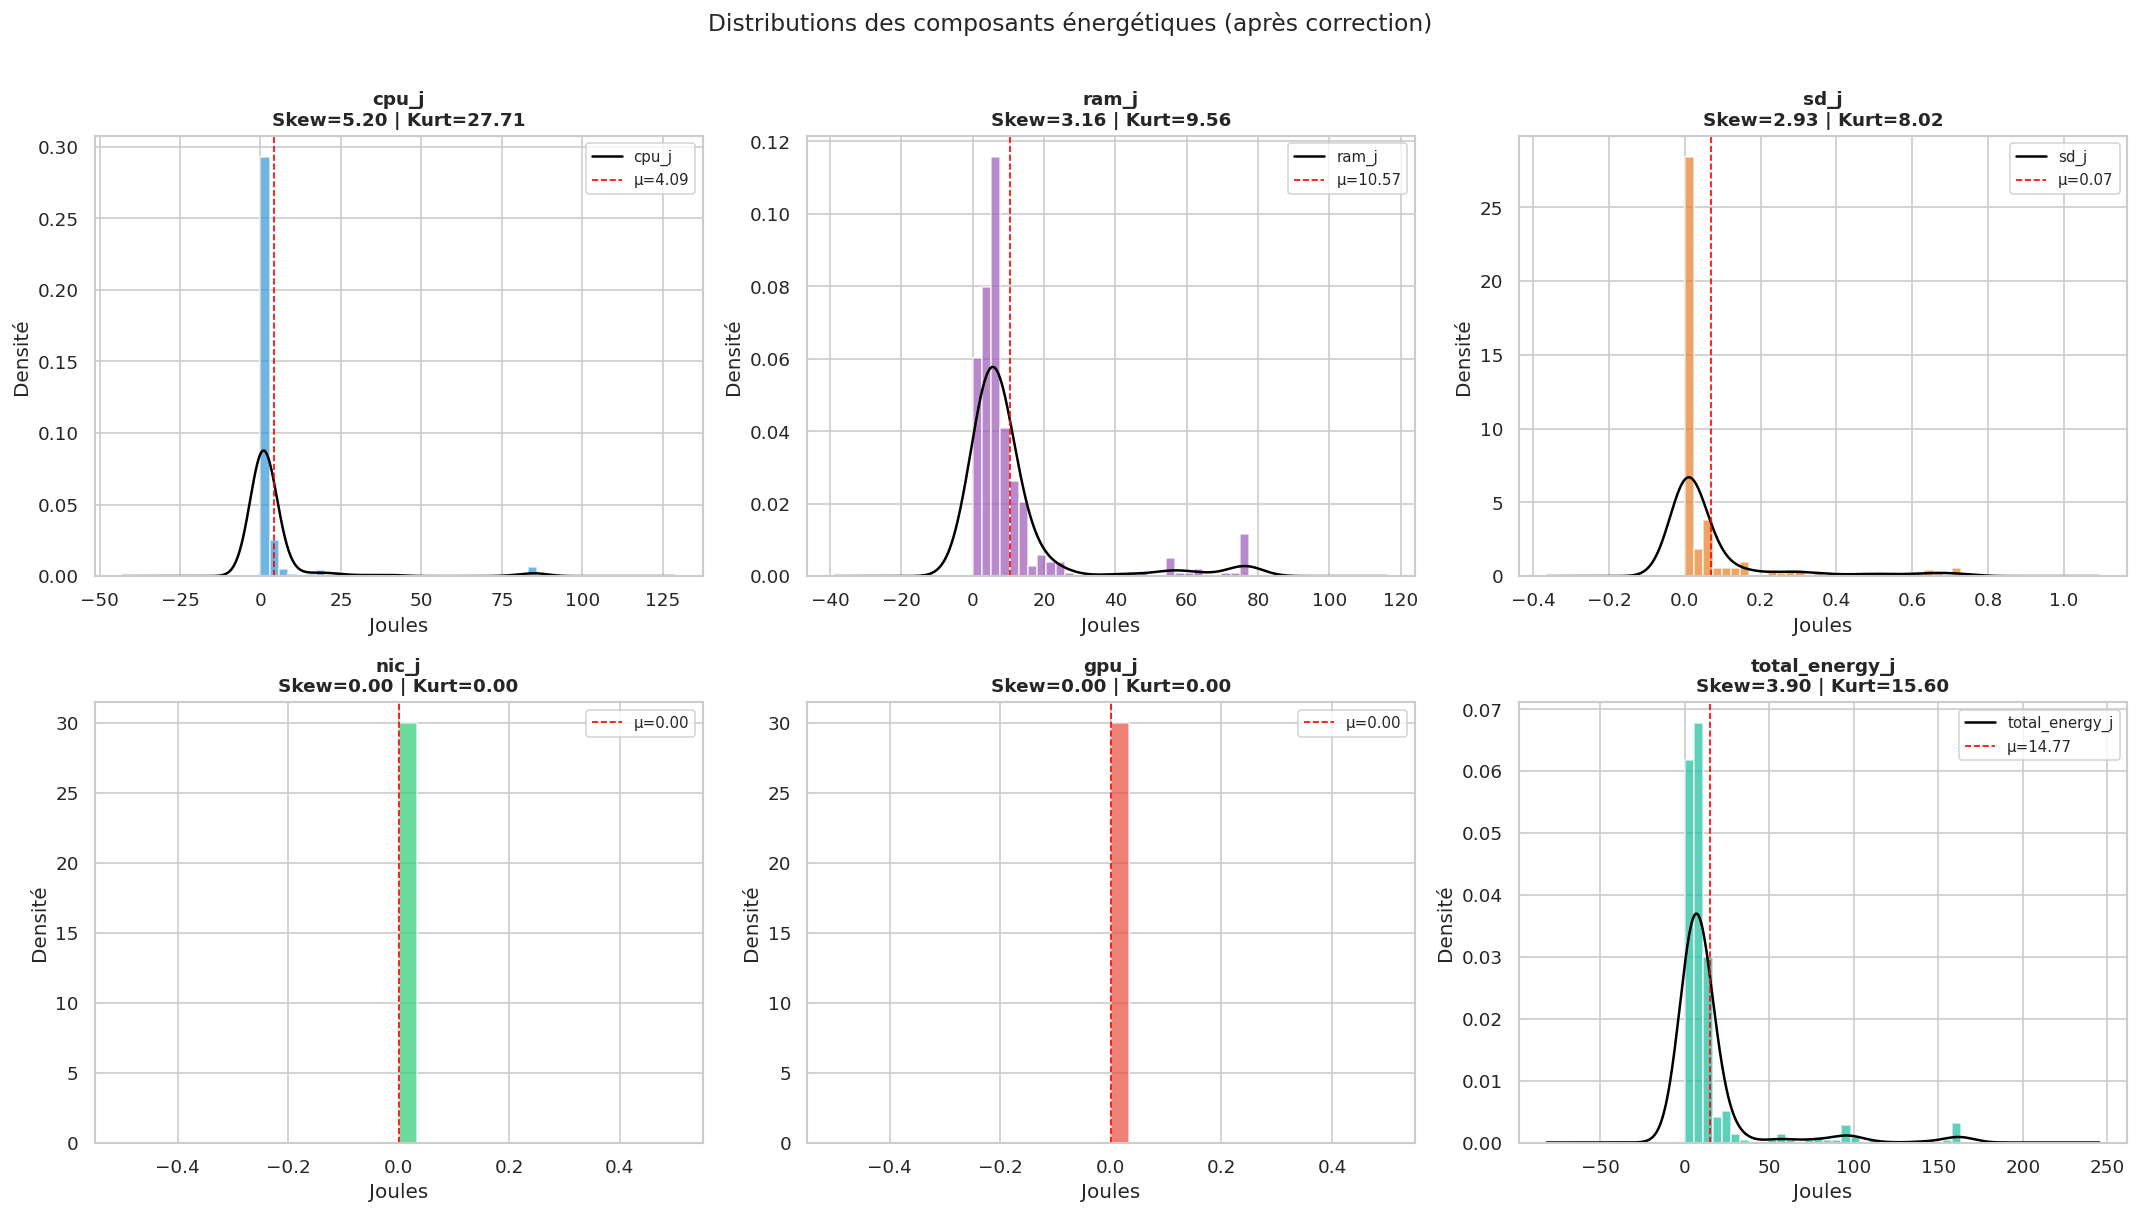

In [23]:
# ── 8.1 Histogrammes + KDE ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = ['#3498db','#9b59b6','#e67e22','#2ecc71','#e74c3c','#1abc9c']

for i, col in enumerate(ENERGY_COLS):
    ax = axes[i]
    data = df_master_clean[col].dropna()
    
    ax.hist(data, bins=30, color=colors[i], alpha=0.7, edgecolor='white', density=True)
    
   
    if data.nunique() > 1 and data.std() > 0:
        try:
            data.plot.kde(ax=ax, color='black', lw=1.5)
        except Exception as e:
            print(f"⚠️ Impossible de tracer le KDE pour {col} : {e}")
    else:
        print(f"ℹ️ KDE sauté pour {col} : données constantes ou uniques.")

    skew = data.skew()
    kurt = data.kurtosis()
    ax.set_title(f'{col}\nSkew={skew:.2f} | Kurt={kurt:.2f}', fontsize=11)
    ax.set_xlabel('Joules')
    ax.set_ylabel('Densité')
    
    if len(data) > 0:
        ax.axvline(data.mean(), color='red', linestyle='--', lw=1, label=f'μ={data.mean():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Distributions des composants énergétiques (après correction)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()

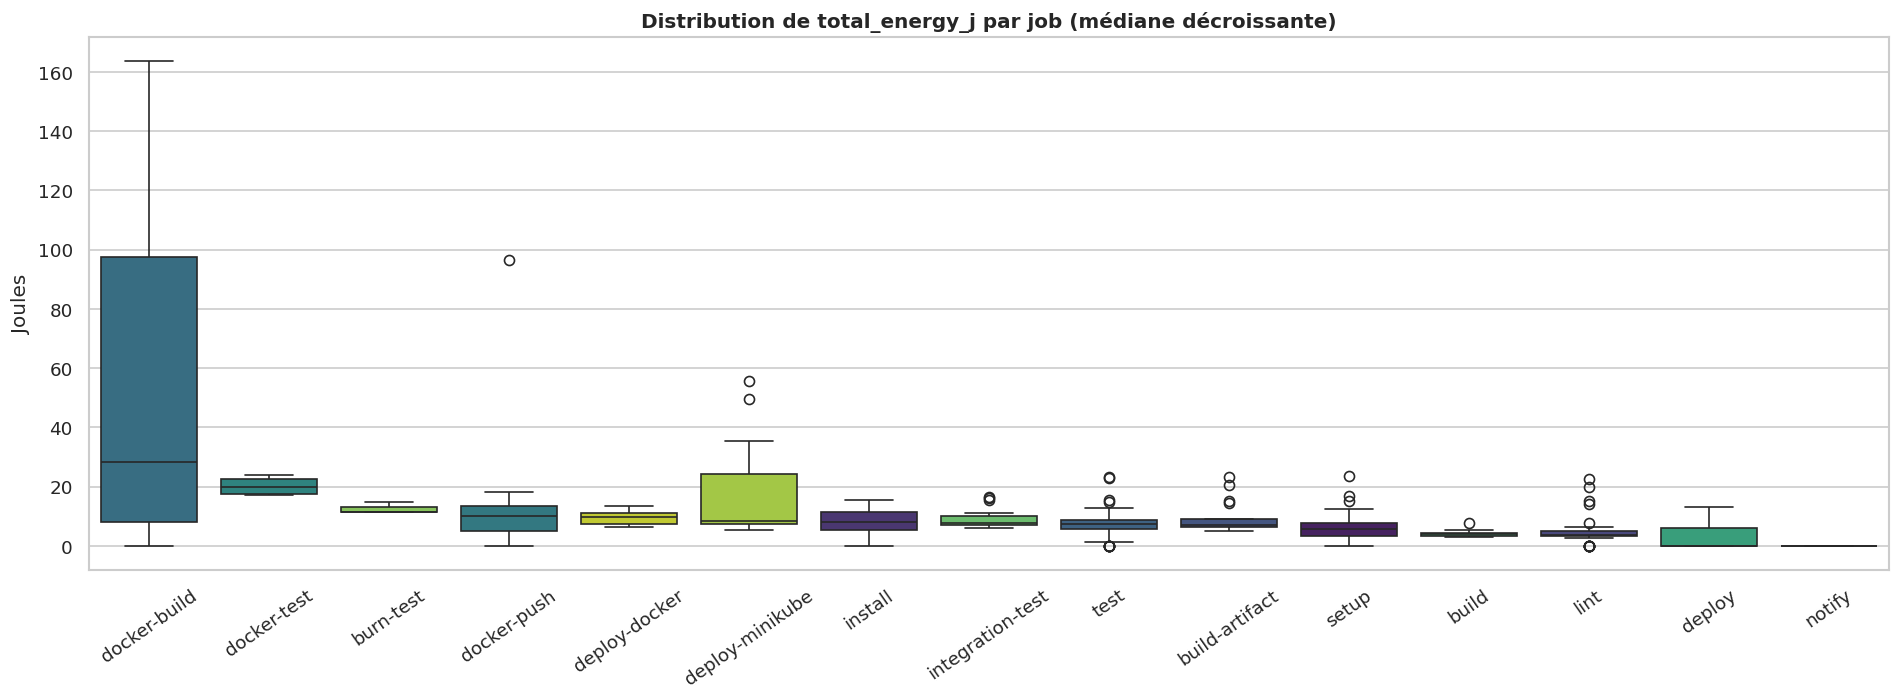

In [24]:
# ── 8.2 Boxplots par job_name ────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
job_order = df_master_clean.groupby('job_name')['total_energy_j'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_master_clean,
    x='job_name', y='total_energy_j',
    order=job_order,
    palette='viridis', hue='job_name', legend=False, ax=ax
)
ax.set_title('Distribution de total_energy_j par job (médiane décroissante)')
ax.set_xlabel('')
ax.set_ylabel('Joules')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('boxplot_jobs.png', bbox_inches='tight')
plt.show()

In [25]:
# ── 8.3 Skewness résumé ─────────────────────────────────────────
skew_df = df_master_clean[ENERGY_COLS].skew().reset_index()
skew_df.columns = ['composant','skewness']
skew_df['interprétation'] = skew_df['skewness'].apply(
    lambda x: 'symétrique' if abs(x)<0.5 else ('légèrement asymétrique' if abs(x)<1 else 'fortement asymétrique')
)
print(skew_df.to_string(index=False))

     composant  skewness        interprétation
         cpu_j  5.199354 fortement asymétrique
         ram_j  3.163591 fortement asymétrique
          sd_j  2.929692 fortement asymétrique
         nic_j  0.000000            symétrique
         gpu_j  0.000000            symétrique
total_energy_j  3.902718 fortement asymétrique


## 9. Corrélations — Heatmap Pearson + SHAP Feature Importance

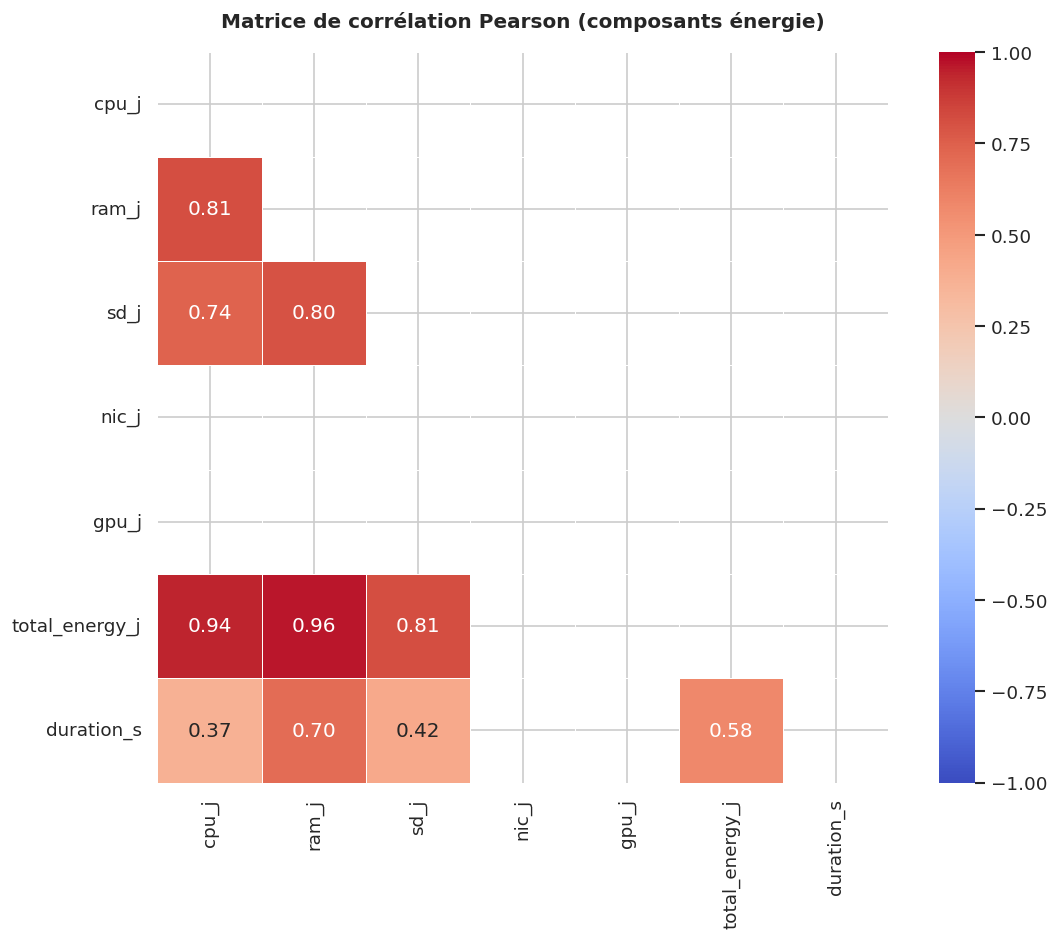

In [26]:
# ── 9.1 Heatmap Pearson ─────────────────────────────────────────
corr_cols = [c for c in ENERGY_COLS + ['duration_s'] if c in df_master_clean.columns]
corr_mat  = df_master_clean[corr_cols].corr(method='pearson')

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax
)
ax.set_title('Matrice de corrélation Pearson (composants énergie)', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Feature Engineering
- Rolling windows (3, 7 runs)
- Ratios d'efficacité (energy / duration)
- Features lag (t-1, t-2)
- Encodage job_name

In [27]:
df_fe = df_master_clean.copy().sort_values(['job_name','date']).reset_index(drop=True)

# ── Rolling windows par job_name ────────────────────────────────
for w in [3, 7]:
    for col in ['total_energy_j','cpu_j','ram_j']:
        if col in df_fe.columns:
            df_fe[f'{col}_roll{w}_mean'] = (
                df_fe.groupby('job_name')[col]
                     .transform(lambda x: x.rolling(w, min_periods=1).mean())
            )
            df_fe[f'{col}_roll{w}_std'] = (
                df_fe.groupby('job_name')[col]
                     .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            )

# ── Ratios d'efficacité ──────────────────────────────────────────
df_fe['energy_per_sec']  = df_fe['total_energy_j'] / (df_fe['duration_s'] + 1e-6)
df_fe['cpu_ram_ratio']   = df_fe['cpu_j'] / (df_fe['ram_j'] + 1e-6)
df_fe['gpu_total_ratio'] = df_fe['gpu_j'] / (df_fe['total_energy_j'] + 1e-6)

# ── Lag features (t-1, t-2) ──────────────────────────────────────
for lag in [1, 2]:
    df_fe[f'total_energy_lag{lag}'] = (
        df_fe.groupby('job_name')['total_energy_j'].shift(lag).fillna(0)
    )

# ── Encodage catégoriel ──────────────────────────────────────────
df_fe['job_encoded']  = df_fe['job_name'].astype('category').cat.codes
df_fe['repo_encoded'] = df_fe['repo_name'].astype('category').cat.codes

new_feats = [c for c in df_fe.columns if c not in df_master_clean.columns]
print(f'✅ {len(new_feats)} nouvelles features créées :')
print(new_feats)
print(f'\nDataFrame final : {df_fe.shape}')

✅ 19 nouvelles features créées :
['total_energy_j_roll3_mean', 'total_energy_j_roll3_std', 'cpu_j_roll3_mean', 'cpu_j_roll3_std', 'ram_j_roll3_mean', 'ram_j_roll3_std', 'total_energy_j_roll7_mean', 'total_energy_j_roll7_std', 'cpu_j_roll7_mean', 'cpu_j_roll7_std', 'ram_j_roll7_mean', 'ram_j_roll7_std', 'energy_per_sec', 'cpu_ram_ratio', 'gpu_total_ratio', 'total_energy_lag1', 'total_energy_lag2', 'job_encoded', 'repo_encoded']

DataFrame final : (398, 36)


## 11. Feature Selection — Random Forest Importance + SHAP

In [28]:
# ── Préparer X, y ───────────────────────────────────────────────
feature_cols = [
    'duration_s','cpu_j','ram_j','sd_j','nic_j','gpu_j',
    'job_encoded','repo_encoded',
    'total_energy_lag1','total_energy_lag2',
    'cpu_j_roll3_mean','ram_j_roll3_mean',
    'total_energy_j_roll3_mean','total_energy_j_roll7_mean',
    'energy_per_sec','cpu_ram_ratio','gpu_total_ratio'
]
feature_cols = [c for c in feature_cols if c in df_fe.columns]

df_model = df_fe[feature_cols + ['total_energy_j']].dropna()
X = df_model[feature_cols].values
y = df_model['total_energy_j'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr_s, y_tr)

r2 = r2_score(y_te, rf.predict(X_te_s))
print(f'✅ Random Forest R² = {r2:.4f}')

# ── Importance RF ────────────────────────────────────────────────
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
imp_df.sort_values('importance', ascending=False, inplace=True)
print('\nTop 10 features :')
print(imp_df.head(10).to_string(index=False))

✅ Random Forest R² = 0.9959

Top 10 features :
                  feature  importance
                    ram_j    0.758744
                    cpu_j    0.130695
            cpu_ram_ratio    0.030120
         cpu_j_roll3_mean    0.029033
total_energy_j_roll3_mean    0.020123
           energy_per_sec    0.007302
               duration_s    0.006372
                     sd_j    0.006230
        total_energy_lag2    0.005161
         ram_j_roll3_mean    0.002342


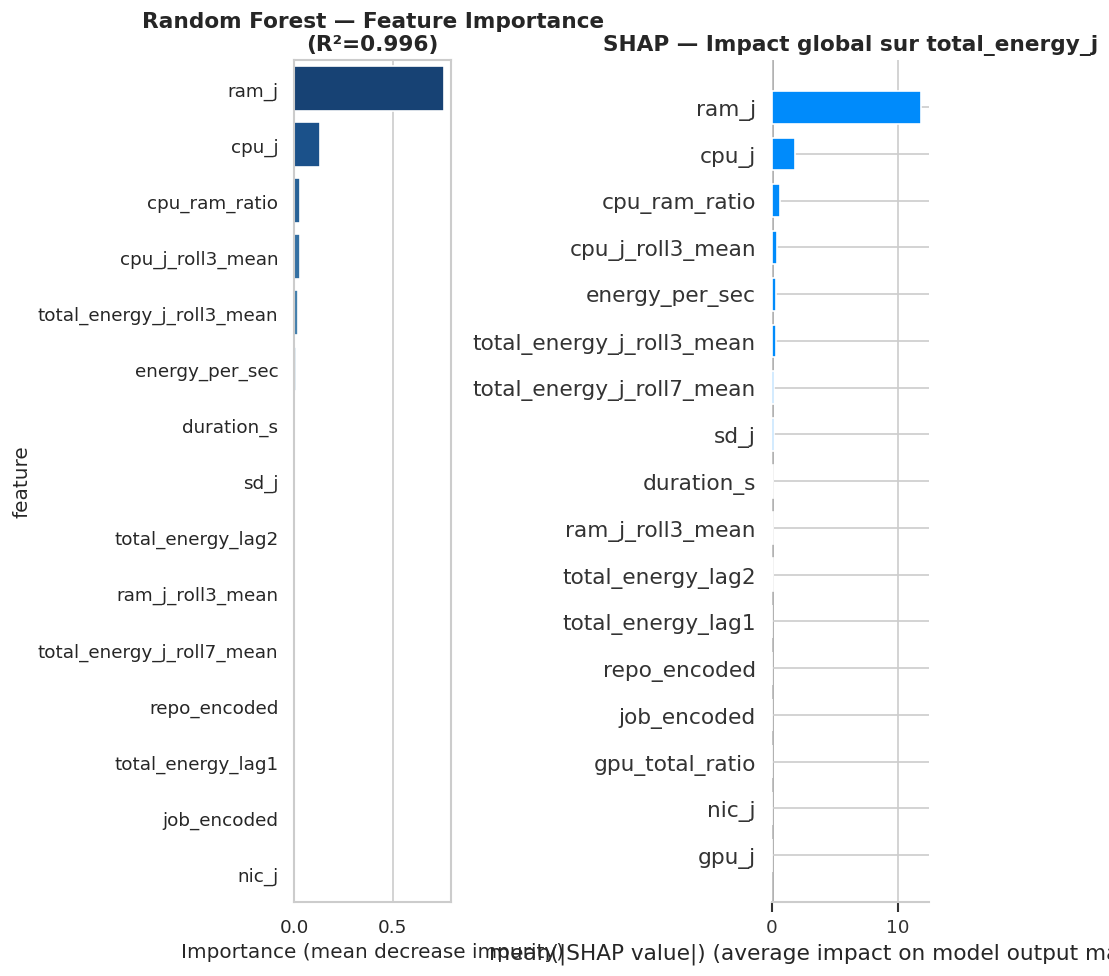

In [29]:
# ── Graphique Feature Importance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot importance RF
top15 = imp_df.head(15)
sns.barplot(ax=axes[0], data=top15, y='feature', x='importance',
            palette='Blues_r', hue='feature', legend=False)
axes[0].set_title(f'Random Forest — Feature Importance\n(R²={r2:.3f})', fontsize=13)
axes[0].set_xlabel('Importance (mean decrease impurity)')

# SHAP values (TreeExplainer)
try:
    explainer  = shap.TreeExplainer(rf)
    shap_vals  = explainer.shap_values(X_te_s[:100])
    shap.summary_plot(shap_vals, X_te_s[:100],
                      feature_names=feature_cols,
                      plot_type='bar', show=False)
    plt.sca(axes[1])
    axes[1].set_title('SHAP — Impact global sur total_energy_j', fontsize=13)
except Exception as e:
    axes[1].text(0.5, 0.5, f'SHAP non calculé\n({e})',
                 ha='center', va='center', fontsize=11)
    axes[1].set_title('SHAP values')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 12. Visualisations approfondies — Consommation Énergétique

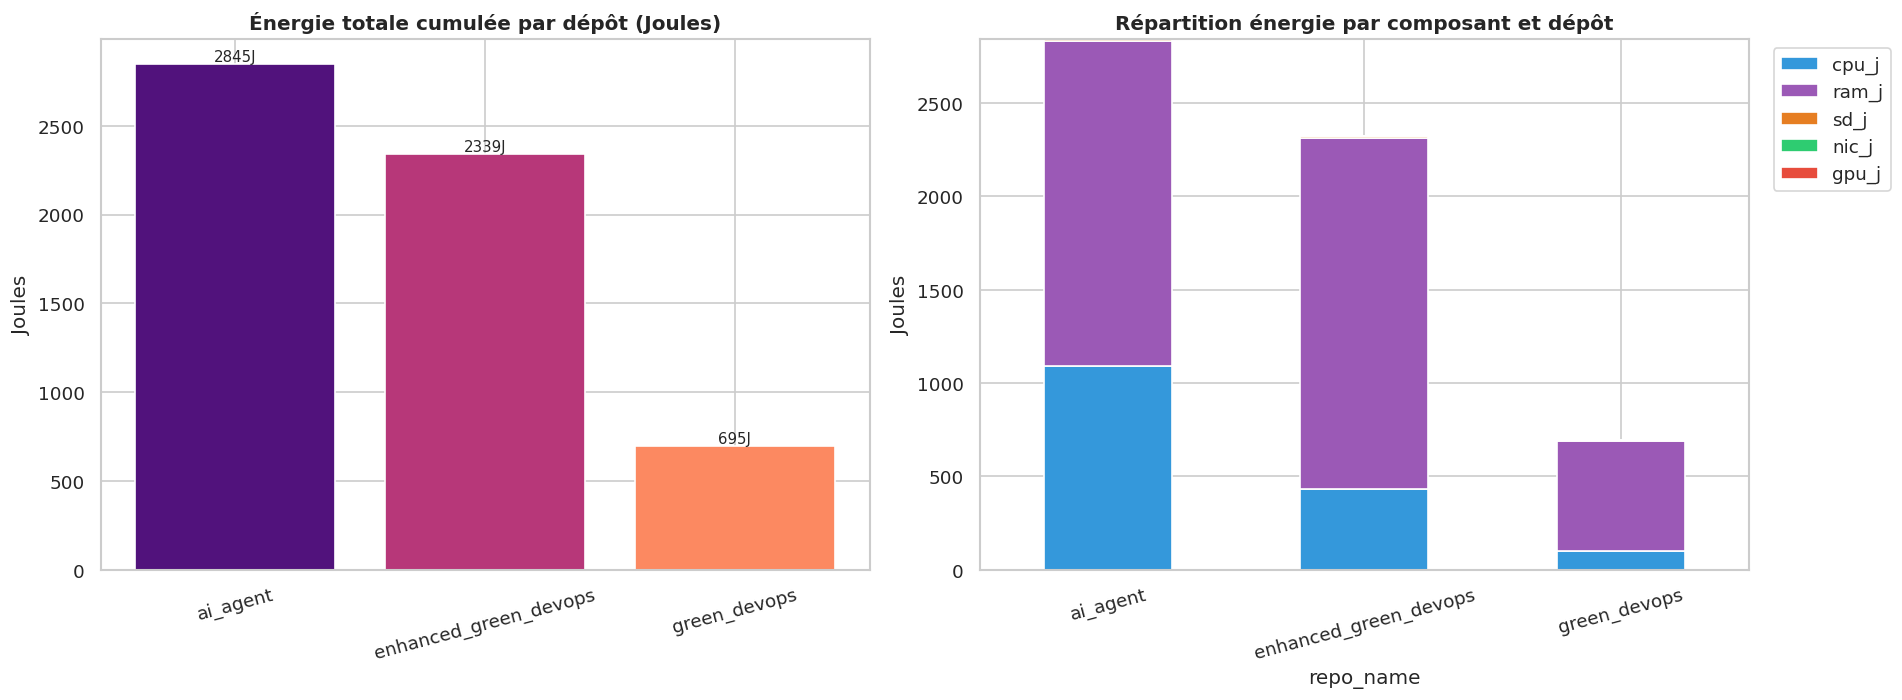

In [30]:
# ── 12.1 Énergie cumulée par repo_name ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

total_repo = (df_master_clean.groupby('repo_name')['total_energy_j']
                .sum().sort_values(ascending=False).reset_index())
total_repo['repo_short'] = total_repo['repo_name'].str.replace('green_energy_org_','', regex=False)

bars = axes[0].bar(total_repo['repo_short'], total_repo['total_energy_j'],
                   color=sns.color_palette('magma', len(total_repo)))
axes[0].set_title('Énergie totale cumulée par dépôt (Joules)')
axes[0].set_ylabel('Joules')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, total_repo['total_energy_j']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.0f}J', ha='center', va='bottom', fontsize=9)

# Répartition des composants (stacked bar)
comp_sum = (df_master_clean.groupby('repo_name')[COMP_COLS].sum())
comp_sum.index = comp_sum.index.str.replace('green_energy_org_','',regex=False)
comp_sum.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#3498db','#9b59b6','#e67e22','#2ecc71','#e74c3c'])
axes[1].set_title('Répartition énergie par composant et dépôt')
axes[1].set_ylabel('Joules')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('energy_by_repo.png', bbox_inches='tight')
plt.show()

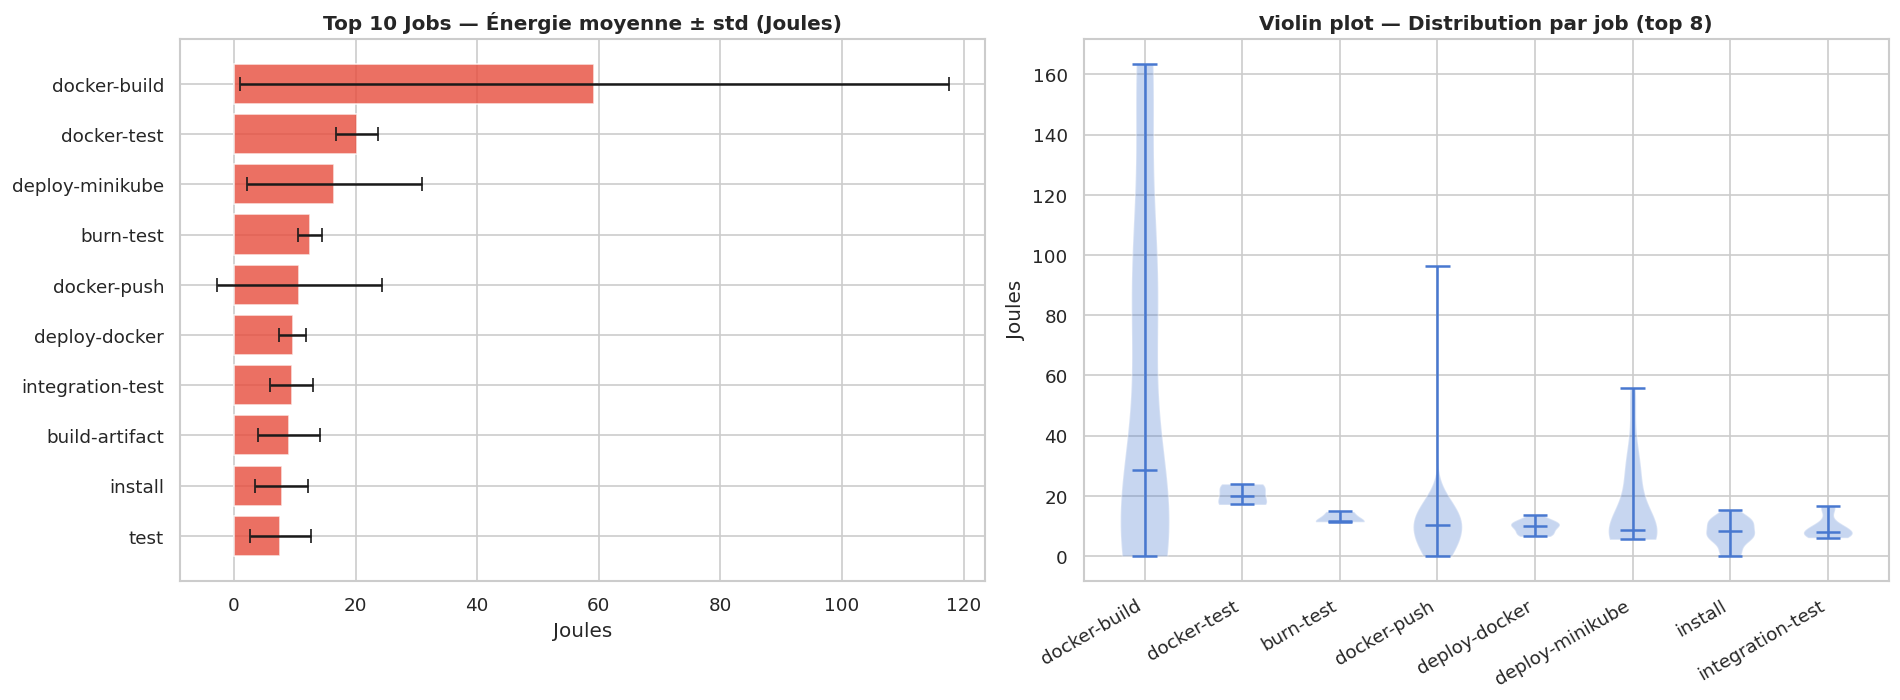

In [31]:
# ── 12.2 Top 10 jobs les plus coûteux ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_jobs_mean = (df_master_clean.groupby('job_name')['total_energy_j']
                   .agg(['mean','std','count']).sort_values('mean', ascending=False).head(10))

axes[0].barh(top_jobs_mean.index[::-1], top_jobs_mean['mean'][::-1],
             xerr=top_jobs_mean['std'][::-1], color='#e74c3c', alpha=0.8, capsize=4)
axes[0].set_title('Top 10 Jobs — Énergie moyenne ± std (Joules)')
axes[0].set_xlabel('Joules')

# Violin plot total_energy_j par job
job_order_v = (df_master_clean.groupby('job_name')['total_energy_j']
                 .median().sort_values(ascending=False).index[:8])
data_v = [df_master_clean[df_master_clean['job_name']==j]['total_energy_j'].values
          for j in job_order_v]
vp = axes[1].violinplot(data_v, showmedians=True, showextrema=True)
axes[1].set_xticks(range(1, len(job_order_v)+1))
axes[1].set_xticklabels(job_order_v, rotation=30, ha='right')
axes[1].set_title('Violin plot — Distribution par job (top 8)')
axes[1].set_ylabel('Joules')

plt.tight_layout()
plt.savefig('top_jobs_energy.png', bbox_inches='tight')
plt.show()

## 13. Analyse Temporelle

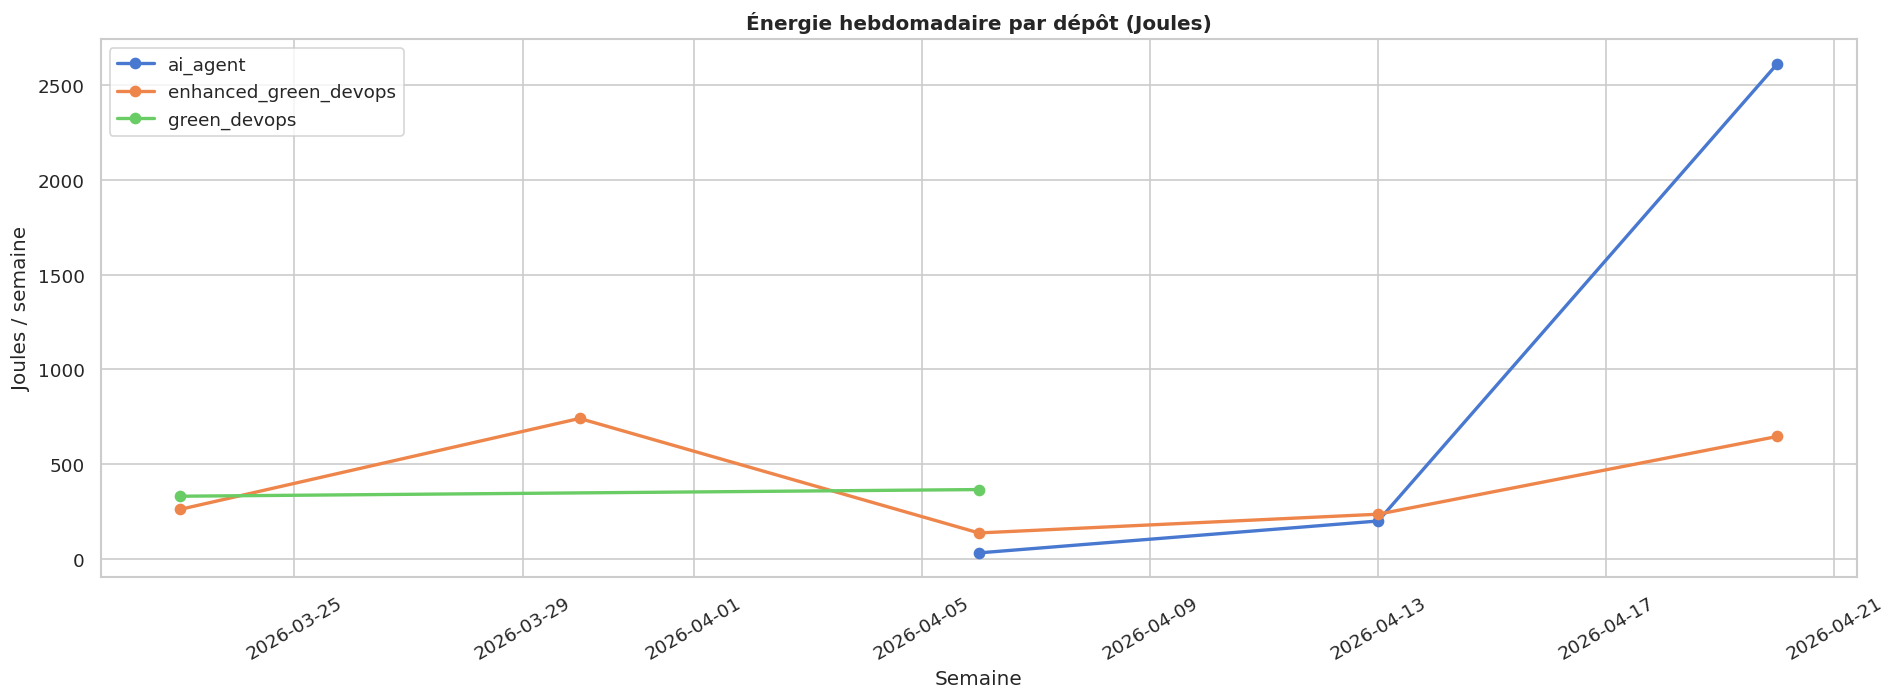

In [32]:
# ── 13.1 Évolution temporelle de l'énergie totale ────────────────
df_ts = df_master_clean.dropna(subset=['date']).copy()
df_ts['week'] = df_ts['date'].dt.to_period('W').dt.start_time

weekly = (df_ts.groupby(['week','repo_name'])['total_energy_j']
             .sum().reset_index())
weekly['repo_short'] = weekly['repo_name'].str.replace('green_energy_org_','',regex=False)

fig, ax = plt.subplots(figsize=(16, 6))
for repo, grp in weekly.groupby('repo_short'):
    ax.plot(grp['week'], grp['total_energy_j'], marker='o', label=repo, linewidth=2)
ax.set_title('Énergie hebdomadaire par dépôt (Joules)')
ax.set_ylabel('Joules / semaine')
ax.set_xlabel('Semaine')
ax.legend()
ax.xaxis.set_tick_params(rotation=30)
plt.tight_layout()
plt.savefig('weekly_energy.png', bbox_inches='tight')
plt.show()

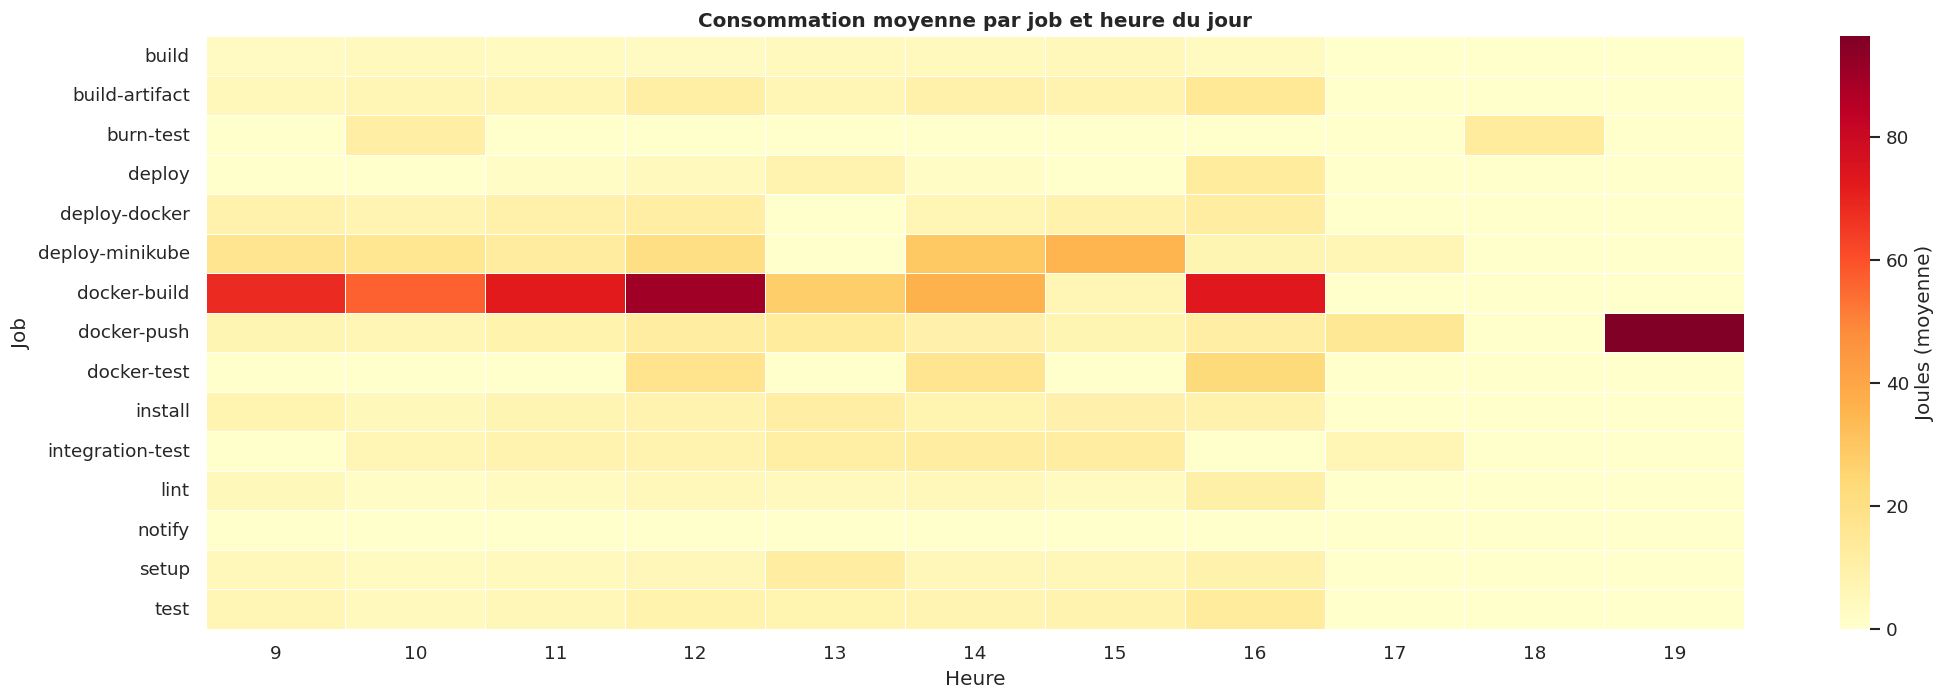

In [33]:
# ── 13.2 Heatmap job × heure de la journée ──────────────────────
df_ts['hour'] = df_ts['date'].dt.hour
pivot_heatmap = df_ts.pivot_table(
    index='job_name', columns='hour',
    values='total_energy_j', aggfunc='mean', fill_value=0
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot_heatmap, cmap='YlOrRd', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Joules (moyenne)'}, ax=ax)
ax.set_title('Consommation moyenne par job et heure du jour')
ax.set_xlabel('Heure')
ax.set_ylabel('Job')
plt.tight_layout()
plt.savefig('heatmap_job_hour.png', bbox_inches='tight')
plt.show()

## 14. Analyse Pipelines — Distribution & Évolution

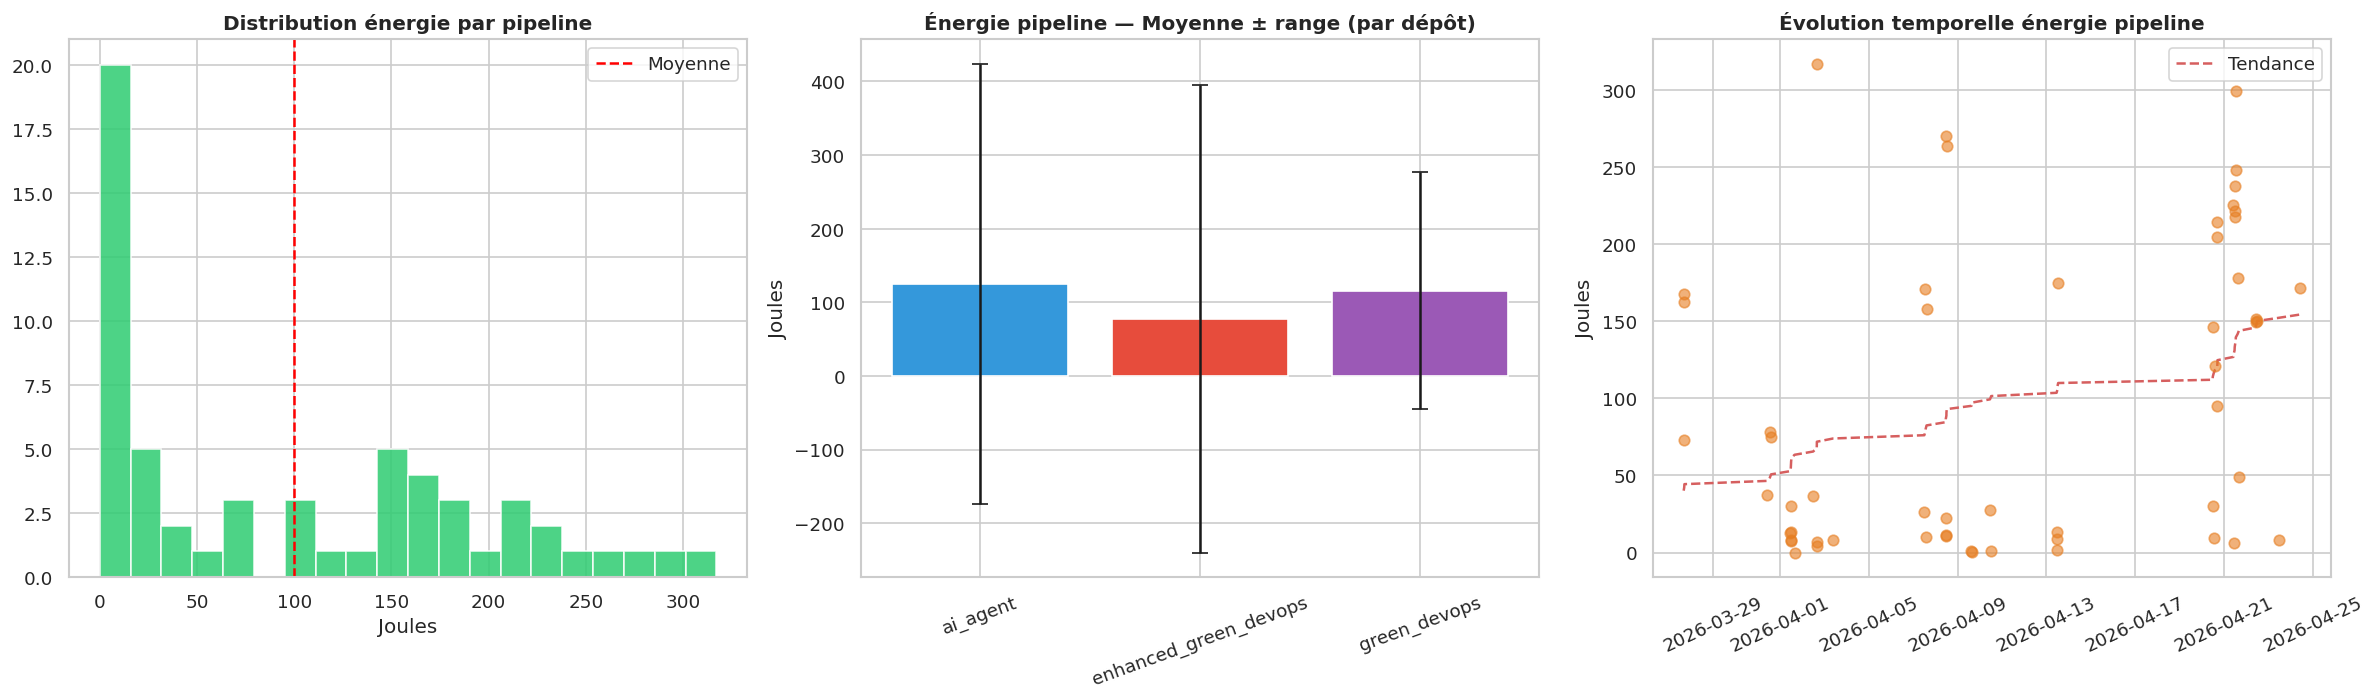

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogramme énergie pipeline
axes[0].hist(df_pipe_clean['total_pipeline_energy_j'].dropna(), bins=20,
             color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].axvline(df_pipe_clean['total_pipeline_energy_j'].mean(), color='red',
                linestyle='--', label='Moyenne')
axes[0].set_title('Distribution énergie par pipeline')
axes[0].set_xlabel('Joules')
axes[0].legend()

# Par dépôt
pipe_repo = (df_pipe_clean.groupby('repo_folder')['total_pipeline_energy_j']
               .agg(['mean','min','max']).reset_index())
x_ = range(len(pipe_repo))
axes[1].bar(x_, pipe_repo['mean'], yerr=pipe_repo['max']-pipe_repo['min'],
            color=['#3498db','#e74c3c','#9b59b6'][:len(pipe_repo)], capsize=5)
axes[1].set_xticks(x_)
axes[1].set_xticklabels(pipe_repo['repo_folder'].str.replace('green_energy_org_','',regex=False),
                        rotation=20)
axes[1].set_title('Énergie pipeline — Moyenne ± range (par dépôt)')
axes[1].set_ylabel('Joules')

# Trend temporel pipelines
df_pipe_clean_dt = df_pipe_clean.dropna(subset=['date']).sort_values('date')
axes[2].scatter(df_pipe_clean_dt['date'], df_pipe_clean_dt['total_pipeline_energy_j'],
                alpha=0.6, c='#e67e22', s=40, zorder=3)
if len(df_pipe_clean_dt) > 2:
    z = np.polyfit(range(len(df_pipe_clean_dt)),
                   df_pipe_clean_dt['total_pipeline_energy_j'], 1)
    p = np.poly1d(z)
    axes[2].plot(df_pipe_clean_dt['date'], p(range(len(df_pipe_clean_dt))),
                 'r--', lw=1.5, label='Tendance')
    axes[2].legend()
axes[2].set_title('Évolution temporelle énergie pipeline')
axes[2].set_ylabel('Joules')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('pipeline_analysis.png', bbox_inches='tight')
plt.show()

## 15. Analyse Granularité — Puissance moyenne par composant et job

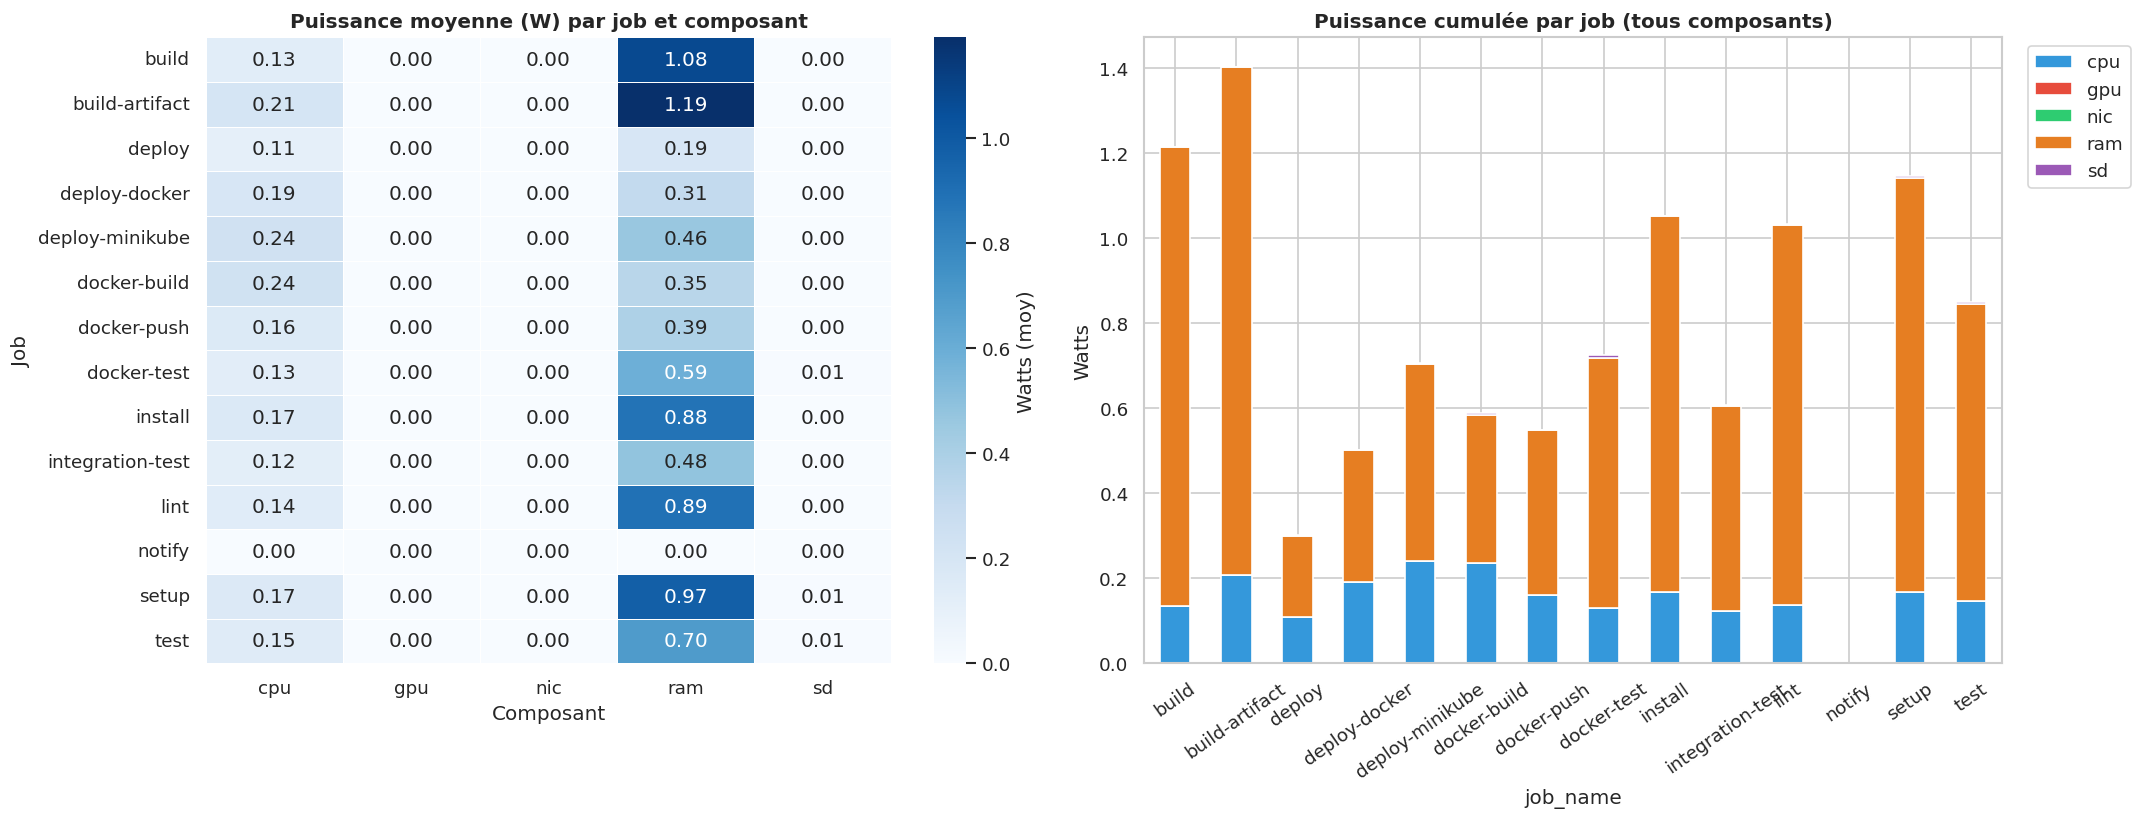

In [35]:
# ── Pivot : job × composant → avg_power_w ─────────────────────────
gran_pivot = (df_gran_clean.groupby(['job_name','component'])['avg_power_w']
                .mean().unstack(fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(gran_pivot, cmap='Blues', annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[0], cbar_kws={'label':'Watts (moy)'})
axes[0].set_title('Puissance moyenne (W) par job et composant')
axes[0].set_xlabel('Composant')
axes[0].set_ylabel('Job')

# Stacked bar
gran_pivot.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6'])
axes[1].set_title('Puissance cumulée par job (tous composants)')
axes[1].set_ylabel('Watts')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.savefig('granularity_analysis.png', bbox_inches='tight')
plt.show()

## 16. Résumé des recommandations d'optimisation

In [37]:
print('='*65)
print('        RAPPORT D OPTIMISATION ÉNERGÉTIQUE CI/CD')
print('='*65)

# Job le plus gourmand
worst = (df_master_clean.groupby('job_name')['total_energy_j']
           .sum().sort_values(ascending=False))
print(f'\n🚨 Job le plus énergivore (total) : {worst.index[0]}  ({worst.iloc[0]:.1f} J)')

# Repo le plus gourmand
worst_repo = (df_master_clean.groupby('repo_name')['total_energy_j']
                .sum().sort_values(ascending=False))
print(f'\n🏭 Dépôt le plus énergivore : {worst_repo.index[0]}')
print(f'   Énergie totale : {worst_repo.iloc[0]:.1f} J')

# Composant dominant
comp_sum = df_master_clean[COMP_COLS].sum().sort_values(ascending=False)
print(f'\n⚡ Composant dominant : {comp_sum.index[0]}  ({comp_sum.iloc[0]:.1f} J)')
print(f'   → {comp_sum.index[0]} représente {comp_sum.iloc[0]/comp_sum.sum()*100:.1f}% de l énergie totale')

# Feature la plus prédictive
print(f'\n🤖 Top 3 features prédictives (RF) :')
for _, row in imp_df.head(3).iterrows():
    print(f'   {row["feature"]:<35} importance={row["importance"]:.4f}')

print(f'\n📈 R² du modèle Random Forest : {r2:.4f}')
print('\n✅ Toutes les visualisations sauvegardées :')
for fname in ['anomaly_report','distributions','boxplot_jobs','correlation_heatmap',
              'feature_importance','energy_by_repo','top_jobs_energy',
              'weekly_energy','heatmap_job_hour','pipeline_analysis','granularity_analysis']:
    print(f'   • {fname}.png')
print('='*65)

        RAPPORT D OPTIMISATION ÉNERGÉTIQUE CI/CD

🚨 Job le plus énergivore (total) : docker-build  (3081.6 J)

🏭 Dépôt le plus énergivore : green_energy_org_ai_agent
   Énergie totale : 2844.7 J

⚡ Composant dominant : ram_j  (4206.8 J)
   → ram_j représente 71.8% de l énergie totale

🤖 Top 3 features prédictives (RF) :
   ram_j                               importance=0.7587
   cpu_j                               importance=0.1307
   cpu_ram_ratio                       importance=0.0301

📈 R² du modèle Random Forest : 0.9959

✅ Toutes les visualisations sauvegardées :
   • anomaly_report.png
   • distributions.png
   • boxplot_jobs.png
   • correlation_heatmap.png
   • feature_importance.png
   • energy_by_repo.png
   • top_jobs_energy.png
   • weekly_energy.png
   • heatmap_job_hour.png
   • pipeline_analysis.png
   • granularity_analysis.png
